# Molecular Solubility Analysis
## Project Objective
The aim of this project is to analyze molecular properties and investigate the factors that affect aqueous solubility. This project will be developed step by step using Python and will later include cheminformatics and machine learning techniques.

In [1]:
import pandas as pd

### Preview the Dataset
'df.head()' displays the first 5 rows of the dataset by default.

It is useful for quickly inspecting:
-Column names
-Example values
-General structure of the dataset

In [2]:
#data seti okur
df = pd.read_csv("data/delaney-processed.csv")

df.head(5)


,Compound ID,ESOL predicted log solubility in mols per litre,Minimum Degree,Molecular Weight,Number of H-Bond Donors,Number of Rings,Number of Rotatable Bonds,Polar Surface Area,measured log solubility in mols per litre,smiles
0,Amigdalin,-0.974,1,457.432,7,3,7,202.32,-0.77,OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)...
1,Fenfuram,-2.885,1,201.225,1,2,2,42.24,-3.30,Cc1occc1C(=O)Nc2ccccc2
2,citral,-2.579,1,152.237,0,0,4,17.07,-2.06,CC(C)=CCCC(C)=CC(=O)
3,Picene,-6.618,2,278.354,0,5,0,0.00,-7.87,c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43
4,Thiophene,-2.232,2,84.143,0,1,0,0.00,-1.33,c1ccsc1


## 1. Dataset Overview
In this section, we will explore the structure and basic characteristics of the dataset.

### Dataset Dimensions

`df.shape` returns the dimensions of the DataFrame in the following format:

(rows, columns)

- Rows represent the observations (molecules).
- Columns represent the variables/features.

In [3]:
df.shape

(1128, 10)

**Observation:** The dataset contains 1,128 molecules and 10 columns.

### Column Names

`df.columns` returns the names of all columns in the DataFrame.

This helps us understand which variables are available for analysis.

In [4]:
df.columns

Index(['Compound ID', 'ESOL predicted log solubility in mols per litre',
       'Minimum Degree', 'Molecular Weight', 'Number of H-Bond Donors',
       'Number of Rings', 'Number of Rotatable Bonds', 'Polar Surface Area',
       'measured log solubility in mols per litre', 'smiles'],
      dtype='str')

### Dataset Information

`df.info()` provides a summary of the DataFrame, including:

- Column names
- Number of non-null values
- Data types
- Memory usage

Common data types:

- `str` → text
- `int64` → integer numbers
- `float64` → decimal numbers

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1128 entries, 0 to 1127
Data columns (total 10 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   Compound ID                                      1128 non-null   str    
 1   ESOL predicted log solubility in mols per litre  1128 non-null   float64
 2   Minimum Degree                                   1128 non-null   int64  
 3   Molecular Weight                                 1128 non-null   float64
 4   Number of H-Bond Donors                          1128 non-null   int64  
 5   Number of Rings                                  1128 non-null   int64  
 6   Number of Rotatable Bonds                        1128 non-null   int64  
 7   Polar Surface Area                               1128 non-null   float64
 8   measured log solubility in mols per litre        1128 non-null   float64
 9   smiles                                   

**Observation:** All columns contain 1,128 non-null values, suggesting that there are no missing values in the dataset.

### Summary Statistics

`df.describe()` provides descriptive statistics for numerical columns.

- `count` → Number of observations
- `mean` → Average value
- `std` → Standard deviation
- `min` → Minimum value
- `25%` → First quartile (Q1)
- `50%` → Median (Q2)
- `75%` → Third quartile (Q3)
- `max` → Maximum value

In [6]:
df.describe().round(2)

,ESOL predicted log solubility in mols per litre,Minimum Degree,Molecular Weight,Number of H-Bond Donors,Number of Rings,Number of Rotatable Bonds,Polar Surface Area,measured log solubility in mols per litre
count,1128.00,1128.00,1128.00,1128.00,1128.00,1128.00,1128.00,1128.00
mean,-2.99,1.06,203.94,0.70,1.39,2.18,34.87,-3.05
std,1.68,0.24,102.74,1.09,1.32,2.64,35.38,2.10
min,-9.70,0.00,16.04,0.00,0.00,0.00,0.00,-11.60
25%,-3.95,1.00,121.18,0.00,0.00,0.00,0.00,-4.32
50%,-2.87,1.00,182.18,0.00,1.00,1.00,26.30,-2.86
75%,-1.84,1.00,270.37,1.00,2.00,3.00,55.44,-1.60
max,1.09,2.00,780.95,11.00,8.00,23.00,268.68,1.58


**Observation:** The mean molecular weight 203 is higher than the median 182, suggesting that the molecular weight distribution may be right-skewed due to some high molecular weight compounds.

## 2. Data Quality & Cleaning

In this section, we will check the dataset for missing values, duplicate records, and potential data quality issues.

### Missing Values

Missing values are data points that are absent from the dataset.

#### Check all columns

`df.isnull().sum()` checks the number of missing values in each column.

- `isnull()` → Returns `True` if a value is missing and `False` otherwise.
- `sum()` → Counts the `True` values in each column.

#### Check a single column

`df["Column Name"].isnull().sum()` checks the number of missing values in only the selected column.

In [7]:
df.isnull().sum()

Compound ID                                        0
ESOL predicted log solubility in mols per litre    0
Minimum Degree                                     0
Molecular Weight                                   0
Number of H-Bond Donors                            0
Number of Rings                                    0
Number of Rotatable Bonds                          0
Polar Surface Area                                 0
measured log solubility in mols per litre          0
smiles                                             0
dtype: int64

In [8]:
df["Minimum Degree"].isnull().sum()

np.int64(0)

**Observation:** No missing values were found in the dataset. The `Minimum Degree` column was also checked individually and contains no missing values.

### Duplicate Records

Duplicate records are rows that appear more than once in the dataset.

`df.duplicated().sum()` checks the total number of duplicate rows in the DataFrame.

- `duplicated()` → Checks each row and returns `True` if the row is a duplicate and `False` otherwise.
- `sum()` → Counts the `True` values.
- Therefore, the result shows the total number of duplicate rows in the dataset.

In [9]:
df.duplicated().sum()

np.int64(0)

**Observation:** No duplicate records were found in the dataset.

## 3. Exploratory Data Analysis

### Initial Hypothesis

The following molecular properties may influence aqueous solubility:

- Molecular Weight
- Polar Surface Area
- Number of H-Bond Donors
- Number of Rings
- Number of Rotatable Bonds

These relationships will be investigated through exploratory data analysis.

In [10]:
import matplotlib.pyplot as plt

### Molecular Weight Distribution

A histogram is used to visualize the distribution of a numerical variable.

In this section, we will examine the distribution of molecular weights in the dataset.

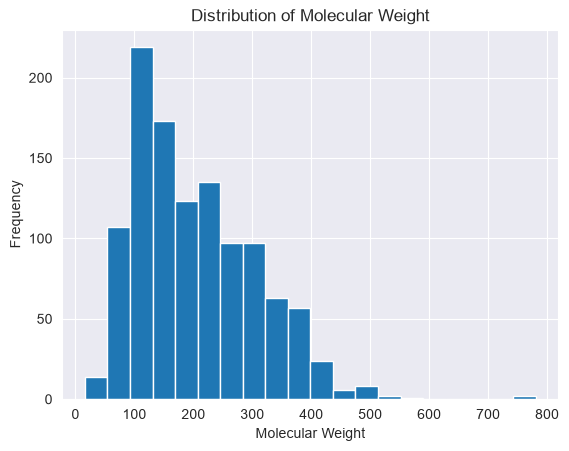

In [11]:
plt.hist(df["Molecular Weight"], bins=20)

plt.xlabel("Molecular Weight")
plt.ylabel("Frequency")
plt.title("Distribution of Molecular Weight")

plt.show()

**Observation:** The molecular weight distribution is right-skewed. Most compounds have relatively low to moderate molecular weights, while a smaller number of high-molecular-weight compounds form a long right tail. This is consistent with the mean molecular weight being higher than the median.

### Molecular Weight vs Solubility

A scatter plot is used to examine the relationship between two numerical variables.

Here, we investigate whether molecular weight is associated with measured aqueous solubility.

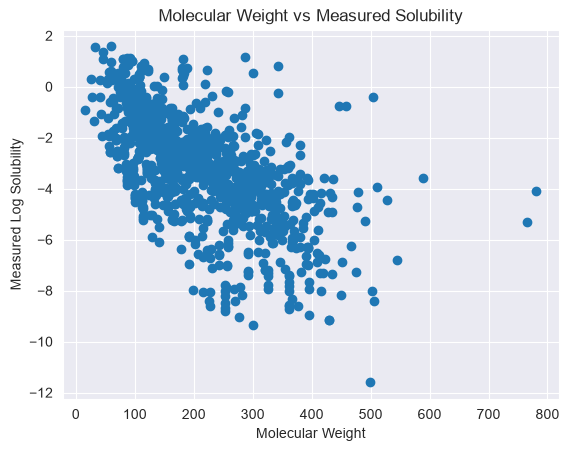

In [12]:
plt.scatter(
    df["Molecular Weight"],
    df["measured log solubility in mols per litre"]
)

plt.xlabel("Molecular Weight")
plt.ylabel("Measured Log Solubility")
plt.title("Molecular Weight vs Measured Solubility")

plt.show()

**Observation:** The scatter plot shows a negative relationship between molecular weight and measured log solubility. In general, compounds with higher molecular weights tend to have lower aqueous solubility. However, the considerable spread in the data suggests that molecular weight alone does not determine solubility and that other molecular properties also play an important role.

### Correlation Between Molecular Weight and Solubility

Correlation measures the strength and direction of the relationship between two numerical variables.

The correlation coefficient ranges from -1 to +1:

- `+1` → Strong positive relationship
- `0` → No linear relationship
- `-1` → Strong negative relationship

In [13]:
df["Molecular Weight"].corr(
    df["measured log solubility in mols per litre"]
)

np.float64(-0.6401894305424647)

**Observation:** The correlation coefficient between molecular weight and measured log solubility is approximately **-0.64**, indicating a moderately strong negative relationship. This supports the pattern observed in the scatter plot: compounds with higher molecular weights tend to have lower aqueous solubility. However, molecular weight alone does not fully explain solubility.

### Polar Surface Area vs Solubility

In this section, we investigate the relationship between polar surface area and measured aqueous solubility.

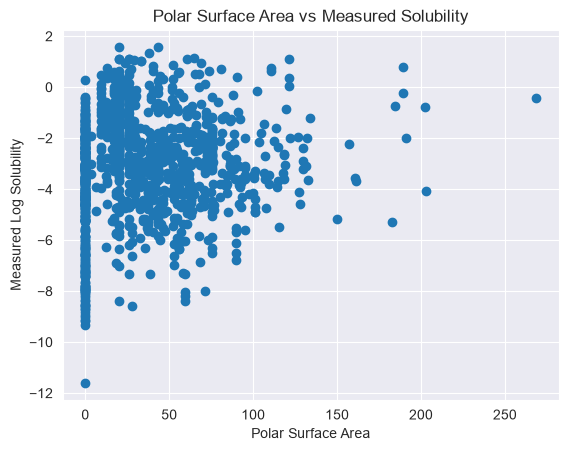

In [14]:
plt.scatter(
    df["Polar Surface Area"],
    df["measured log solubility in mols per litre"]
)

plt.xlabel("Polar Surface Area")
plt.ylabel("Measured Log Solubility")
plt.title("Polar Surface Area vs Measured Solubility")

plt.show()

In [15]:
df["Polar Surface Area"].corr(
    df["measured log solubility in mols per litre"]
).round(2)

np.float64(0.12)

**Observation:** The correlation coefficient between polar surface area and measured log solubility is approximately **0.12**, indicating a very weak positive linear relationship. This is consistent with the scatter plot, where no clear trend is visible. Therefore, polar surface area alone does not appear to strongly explain aqueous solubility in this dataset.

### H-Bond Donors vs Solubility

A box plot is used to compare the distribution of measured solubility across different numbers of hydrogen bond donors.

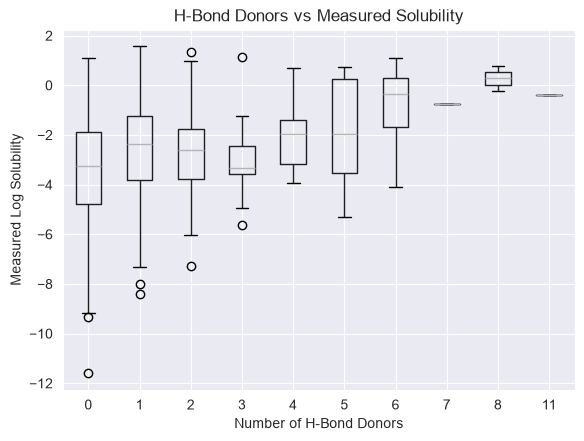

In [16]:
df.boxplot(
    column="measured log solubility in mols per litre",
    by="Number of H-Bond Donors"
)

plt.xlabel("Number of H-Bond Donors")
plt.ylabel("Measured Log Solubility")
plt.title("H-Bond Donors vs Measured Solubility")
plt.suptitle("")

plt.show()

In [17]:
df["Number of H-Bond Donors"].value_counts().sort_index(ascending=True)

Number of H-Bond Donors
0     635
1     307
2     137
3      22
4      11
5       6
6       6
7       1
8       2
11      1
Name: count, dtype: int64

**Observation:** The box plot suggests that measured log solubility may tend to increase as the number of H-bond donors increases. However, the groups are highly imbalanced. Most compounds contain 0–2 H-bond donors, while groups with higher donor counts contain very few observations. Therefore, the apparent trend at higher H-bond donor counts should be interpreted with caution.

### Number of Rings vs Solubility

In this section, we compare the average measured log solubility of compounds with different numbers of rings.

In [18]:
ring_solubility = df.groupby("Number of Rings")[
    "measured log solubility in mols per litre"
].mean()

ring_solubility

Number of Rings
0   -1.912486
1   -2.548288
2   -3.959548
3   -4.377543
4   -4.840317
5   -6.763625
6   -7.099250
7   -5.611333
8   -4.687000
Name: measured log solubility in mols per litre, dtype: float64

In [19]:
df["Number of Rings"].value_counts().sort_index()

Number of Rings
0    317
1    386
2    221
3    116
4     63
5     16
6      4
7      3
8      2
Name: count, dtype: int64

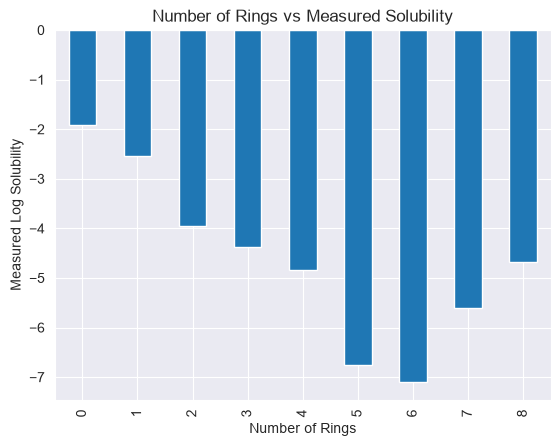

In [20]:
ring_solubility.plot(kind="bar")

plt.xlabel("Number of Rings")
plt.ylabel("Measured Log Solubility")
plt.title("Number of Rings vs Measured Solubility")

plt.show()

**Observation:** The average measured log solubility generally decreases as the number of rings increases, particularly from 0 to 5 rings. This suggests that compounds with more rings tend to have lower aqueous solubility. However, compounds with 6–8 rings are represented by very few observations, so the apparent changes in these groups should be interpreted with caution.

### Rotatable Bonds vs Solubility

In this section, we investigate how the number of rotatable bonds is associated with measured aqueous solubility.

In [21]:
df["Number of Rotatable Bonds"].unique()

array([ 7,  2,  4,  0,  1,  3, 11,  8,  5,  6,  9, 10, 15, 23, 14, 12, 16,
       13, 17])

In [22]:
df["Number of Rotatable Bonds"].value_counts().sort_index()

Number of Rotatable Bonds
0     361
1     232
2     174
3     102
4      86
5      57
6      40
7      22
8      24
9       9
10      6
11      1
12      4
13      2
14      3
15      1
16      2
17      1
23      1
Name: count, dtype: int64

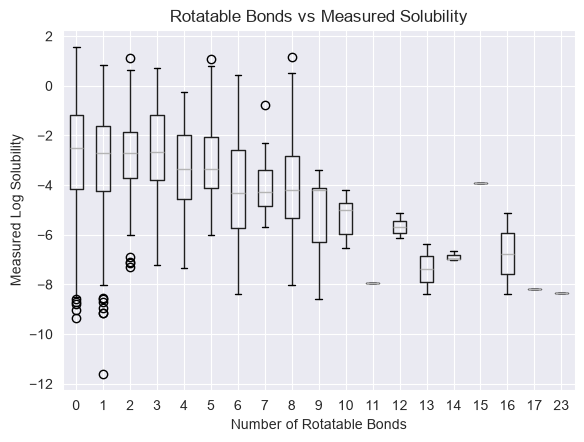

In [23]:
df.boxplot(
    column="measured log solubility in mols per litre",
    by="Number of Rotatable Bonds"
)

plt.xlabel("Number of Rotatable Bonds")
plt.ylabel("Measured Log Solubility")
plt.title("Rotatable Bonds vs Measured Solubility")
plt.suptitle("")

plt.show()

In [24]:
df["Number of Rotatable Bonds"].corr(
    df["measured log solubility in mols per litre"]
).round(2)

np.float64(-0.24)

**Observation:** The correlation coefficient between the number of rotatable bonds and measured log solubility is approximately **-0.24**, indicating a weak negative linear relationship. Compounds with more rotatable bonds tend to have slightly lower aqueous solubility, but the relationship is not strong. Therefore, the number of rotatable bonds alone does not appear to be a strong predictor of solubility.

### Correlation Matrix and Heatmap

A correlation matrix is used to examine the linear relationships among multiple molecular properties and measured solubility simultaneously.

In [25]:
selected_columns = df[[
    "Molecular Weight",
    "Polar Surface Area",
    "Number of H-Bond Donors",
    "Number of Rings",
    "Number of Rotatable Bonds",
    "measured log solubility in mols per litre"
]]

In [26]:
correlation_matrix = selected_columns.corr()

correlation_matrix

,Molecular Weight,Polar Surface Area,Number of H-Bond Donors,Number of Rings,Number of Rotatable Bonds,measured log solubility in mols per litre
Molecular Weight,1.000000,0.475440,0.254877,0.652521,0.396894,-0.640189
Polar Surface Area,0.475440,1.000000,0.755932,0.308606,0.286723,0.123210
Number of H-Bond Donors,0.254877,0.755932,1.000000,0.211087,0.077002,0.209429
Number of Rings,0.652521,0.308606,0.211087,1.000000,-0.136654,-0.512279
Number of Rotatable Bonds,0.396894,0.286723,0.077002,-0.136654,1.000000,-0.244256
measured log solubility in mols per litre,-0.640189,0.123210,0.209429,-0.512279,-0.244256,1.000000


In [27]:
import seaborn as sns

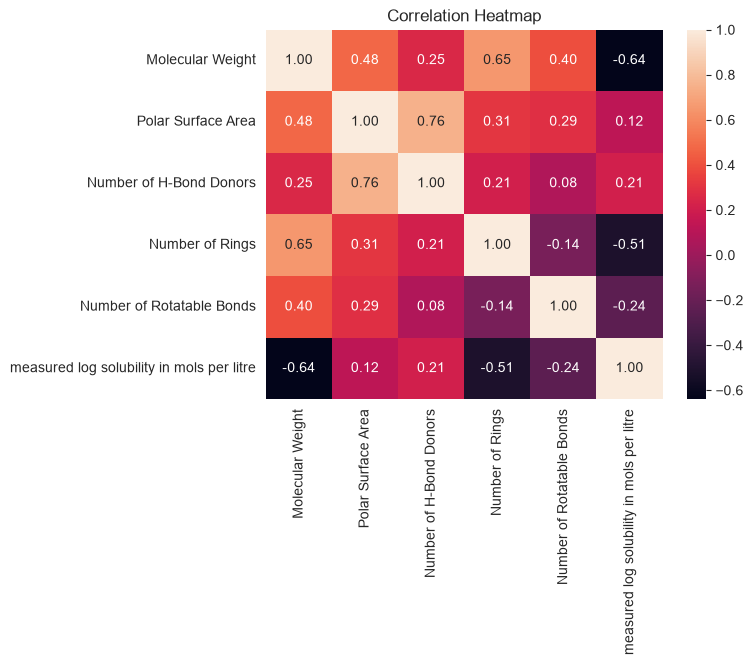

In [28]:
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

**Observation:** The correlation heatmap shows that molecular weight has the strongest negative correlation with measured log solubility (**-0.64**), followed by the number of rings (**-0.51**). Polar surface area and H-bond donors show weak positive correlations with solubility, while rotatable bonds show a weak negative correlation. Some molecular descriptors are also correlated with each other, particularly polar surface area and H-bond donors (**0.76**) and molecular weight and number of rings (**0.65**). These relationships suggest that molecular properties may interact and should not be interpreted independently.

### ESOL Predicted vs Measured Solubility

In this section, we compare the ESOL-predicted solubility values with the experimentally measured solubility values.

A strong agreement between predicted and measured values would indicate that the ESOL model captures the solubility patterns in the dataset reasonably well.

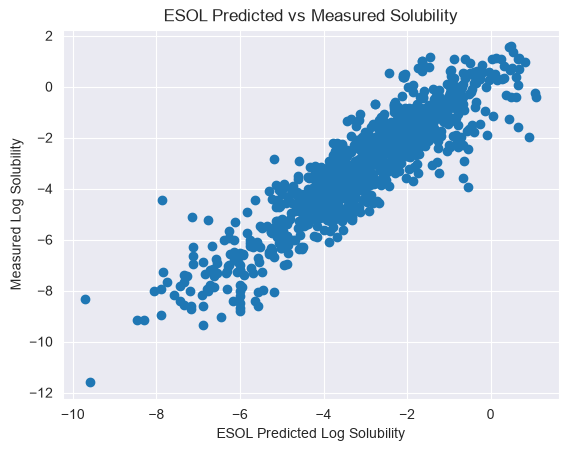

In [29]:
plt.scatter(
    df["ESOL predicted log solubility in mols per litre"],
    df["measured log solubility in mols per litre"]
)

plt.xlabel("ESOL Predicted Log Solubility")
plt.ylabel("Measured Log Solubility")
plt.title("ESOL Predicted vs Measured Solubility")
plt.show()

In [30]:
df["ESOL predicted log solubility in mols per litre"].corr(
    df["measured log solubility in mols per litre"]
).round(2)

np.float64(0.91)

**Observation:** The ESOL-predicted and experimentally measured log solubility values show a strong positive correlation (**r = 0.91**). This indicates that the ESOL predictions closely follow the overall trend of the experimental measurements. However, a high correlation does not necessarily mean that the predictions are perfectly accurate.

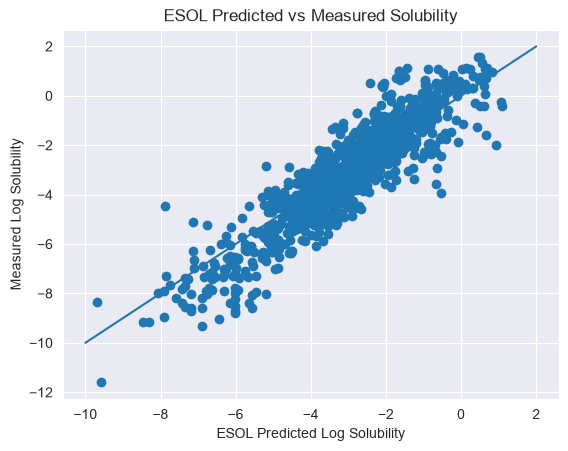

In [31]:
plt.scatter(
    df["ESOL predicted log solubility in mols per litre"],
    df["measured log solubility in mols per litre"]
)

plt.plot([-10, 2], [-10, 2])

plt.xlabel("ESOL Predicted Log Solubility")
plt.ylabel("Measured Log Solubility")
plt.title("ESOL Predicted vs Measured Solubility")
plt.show()

**Observation:** The ESOL-predicted and experimentally measured log solubility values show a strong positive correlation (**r = 0.91**). Most observations are distributed relatively close to the ideal prediction line (y = x), indicating good overall agreement between predicted and measured values. However, some compounds deviate noticeably from the ideal line, showing that the ESOL model does not predict every compound equally accurately. A high correlation indicates strong agreement in the overall trend but does not imply perfect predictive accuracy.

### Prediction Error Analysis

Prediction errors (residuals) are calculated to examine the differences between experimentally measured and ESOL-predicted solubility values.

In [32]:
df["Residual"] = (
    df["measured log solubility in mols per litre"]
    - df["ESOL predicted log solubility in mols per litre"]
)

In [33]:
df[[
    "ESOL predicted log solubility in mols per litre",
    "measured log solubility in mols per litre",
    "Residual"
]].head()

,ESOL predicted log solubility in mols per litre,measured log solubility in mols per litre,Residual
0,-0.974,-0.77,0.204
1,-2.885,-3.30,-0.415
2,-2.579,-2.06,0.519
3,-6.618,-7.87,-1.252
4,-2.232,-1.33,0.902


In [34]:
df["Absolute Error"] = df["Residual"].abs()

In [35]:
df[["Residual", "Absolute Error"]].head()

,Residual,Absolute Error
0,0.204,0.204
1,-0.415,0.415
2,0.519,0.519
3,-1.252,1.252
4,0.902,0.902


In [36]:
df["Absolute Error"].mean()

np.float64(0.6978617021276595)

In [37]:
mae = df["Absolute Error"].mean().round(2)
mae

np.float64(0.7)

**Observation:** The Mean Absolute Error (MAE) of the ESOL predictions is approximately **0.70 logS units**. This means that, on average, the predicted log solubility values differ from the experimentally measured values by about 0.70 logS units.

In [38]:
df["Squared Error"] = df["Residual"] ** 2

In [39]:
df[["Residual", "Squared Error"]].head()

,Residual,Squared Error
0,0.204,0.041616
1,-0.415,0.172225
2,0.519,0.269361
3,-1.252,1.567504
4,0.902,0.813604


In [40]:
import numpy as np

In [41]:
mse = df["Squared Error"].mean()
rmse = np.sqrt(mse)

rmse

np.float64(0.9101322725549837)

In [42]:
rmse = np.sqrt(df["Squared Error"].mean()).round(2)
rmse

np.float64(0.91)

**Observation:** The ESOL model has a Mean Absolute Error (MAE) of approximately **0.70 logS units** and a Root Mean Squared Error (RMSE) of approximately **0.91 logS units**. The RMSE is higher than the MAE, suggesting that some compounds have relatively large prediction errors.

### Residual Distribution

The distribution of residuals is examined to understand the prediction errors of the ESOL model.

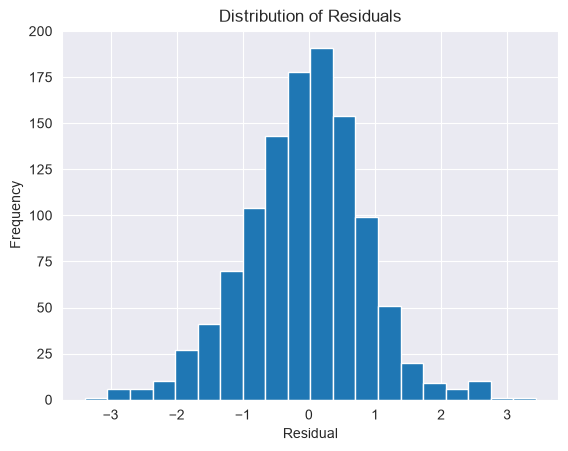

In [43]:
plt.hist(df["Residual"], bins=20)

plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Distribution of Residuals")
plt.show()

In [44]:
df["Residual"].mean().round(2)

np.float64(-0.06)

**Observation:** The residuals are approximately centered around zero, with a mean residual of **-0.06 logS units**. This suggests that the ESOL model does not show a strong systematic tendency to overpredict or underpredict solubility. Most residuals are concentrated near zero, although a small number of relatively large prediction errors are present.

## 4. Machine Learning — Solubility Prediction

In this section, a machine learning model will be developed to predict measured aqueous solubility using molecular descriptors.

In [45]:
X = df[[
    "Molecular Weight",
    "Polar Surface Area",
    "Number of H-Bond Donors",
    "Number of Rings",
    "Number of Rotatable Bonds"
]]

In [46]:
y = df["measured log solubility in mols per litre"]

In [47]:
print(X.shape)
print(y.shape)

(1128, 5)
(1128,)


In [48]:
from sklearn.model_selection import train_test_split

In [49]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [50]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (902, 5)
X_test: (226, 5)
y_train: (902,)
y_test: (226,)


In [51]:
from sklearn.linear_model import LinearRegression

In [52]:
model = LinearRegression()

In [53]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](5,)","[-0.01, 0.03, 0.11,-0.44,-0.15]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](5,)","['Molecular Weight','Polar Surface Area','Number of H-Bond Donors', 'Number of Rings','Number of Rotatable Bonds']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-0.5891
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(5)


In [54]:
y_pred = model.predict(X_test)

In [55]:
y_pred[:10]

array([-1.66640848, -1.8625076 , -2.04687765, -1.66640848, -6.13324657,
       -2.0405524 , -3.90250421, -0.49555081, -6.81366539, -2.74603829])

In [56]:
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
1091,-2.540,-1.666408
898,-2.253,-1.862508
739,-2.484,-2.046878
140,-2.540,-1.666408
1019,-7.200,-6.133247
527,-1.190,-2.040552
812,-4.314,-3.902504
481,-2.190,-0.495551
1120,-7.660,-6.813665
827,-2.570,-2.746038


In [57]:
from sklearn.metrics import mean_absolute_error

In [58]:
mae = round(mean_absolute_error(y_test, y_pred), 2)
mae

0.9

In [59]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)

In [60]:
rmse = round(np.sqrt(mse), 2)
rmse

np.float64(1.21)

In [61]:
from sklearn.metrics import r2_score

In [62]:
r2 = round(r2_score(y_test, y_pred), 2)
r2

0.69

**Observation:** The Linear Regression model achieved an **MAE of 0.90 logS units**, an **RMSE of 1.21 logS units**, and an **R² score of 0.69** on the test set. The R² value indicates that the model explains approximately 69% of the variation in measured log solubility within the test data. The higher RMSE compared with MAE suggests that some compounds have relatively large prediction errors.

In [63]:
model.coef_

array([-0.01315296,  0.03129632,  0.11009257, -0.43501045, -0.15487442])

In [64]:
pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

,Feature,Coefficient
0,Molecular Weight,-0.013153
1,Polar Surface Area,0.031296
2,Number of H-Bond Donors,0.110093
3,Number of Rings,-0.435010
4,Number of Rotatable Bonds,-0.154874


In [65]:
model.intercept_

np.float64(-0.5890515034176307)

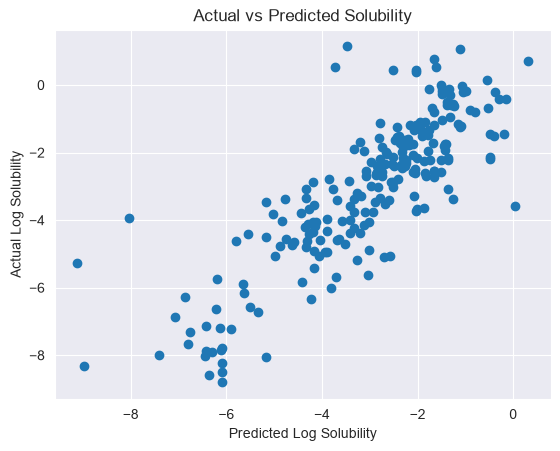

In [66]:
plt.scatter(
    y_pred,
    y_test
)

plt.xlabel("Predicted Log Solubility")
plt.ylabel("Actual Log Solubility")
plt.title("Actual vs Predicted Solubility")
plt.show()

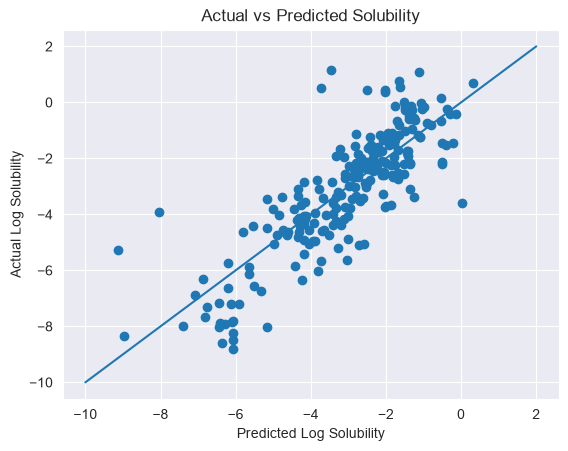

In [67]:
plt.scatter(
    y_pred,
    y_test
)

plt.plot([-10, 2], [-10, 2])

plt.xlabel("Predicted Log Solubility")
plt.ylabel("Actual Log Solubility")
plt.title("Actual vs Predicted Solubility")
plt.show()

**Observation:** The predicted and actual solubility values generally follow the ideal prediction line, indicating that the Linear Regression model captures the overall solubility pattern. However, the points are scattered both above and below the line, showing that prediction errors are present. Most predictions are relatively close to the ideal line, while a smaller number of compounds show larger deviations.

In [68]:
residuals = y_test - y_pred

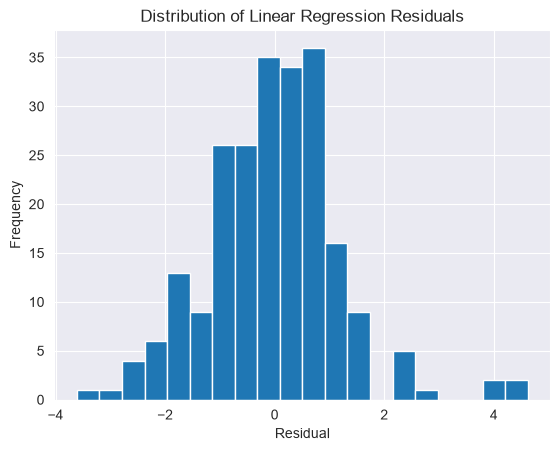

In [69]:
plt.hist(residuals, bins=20)

plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Distribution of Linear Regression Residuals")
plt.show()

In [70]:
round(residuals.mean(), 2)

np.float64(-0.02)

**Observation:** The residuals are mostly concentrated around zero, with a mean residual of approximately **-0.02 logS units**. This suggests that the Linear Regression model does not show a strong systematic tendency to overpredict or underpredict solubility. However, a small number of relatively large residuals are present, which is consistent with the RMSE being higher than the MAE.

In [71]:
esol_test_pred = df.loc[
    y_test.index,
    "ESOL predicted log solubility in mols per litre"
]

In [72]:
len(esol_test_pred)

226

In [73]:
esol_mae = round(mean_absolute_error(y_test, esol_test_pred), 2)
esol_mae

0.71

In [74]:
esol_mse = mean_squared_error(y_test, esol_test_pred)

esol_rmse = round(np.sqrt(esol_mse), 2)

esol_rmse

np.float64(0.96)

In [75]:
esol_r2 = round(r2_score(y_test, esol_test_pred), 2)
esol_r2

0.81

### Model Comparison

The Linear Regression model and the ESOL predictions were evaluated on the same test set to ensure a fair comparison.

In [76]:
model_comparison = pd.DataFrame({
    "Model": ["Linear Regression", "ESOL"],
    "MAE": [mae, esol_mae],
    "RMSE": [rmse, esol_rmse],
    "R²": [r2, esol_r2]
})

model_comparison

,Model,MAE,RMSE,R²
0,Linear Regression,0.90,1.21,0.69
1,ESOL,0.71,0.96,0.81


In [77]:
y_train_pred = model.predict(X_train)

In [78]:
y_train_mae = round(mean_absolute_error(y_train, y_train_pred), 2)
y_train_mae

0.93

In [79]:
train_mse = mean_squared_error(y_train, y_train_pred)

train_rmse = round(np.sqrt(train_mse), 2)
train_rmse

np.float64(1.17)

In [80]:
train_r2 = round(r2_score(y_train, y_train_pred), 2)
train_r2

0.68

### Train vs Test Performance

The training and test performance of the Linear Regression model were compared to evaluate its generalization ability.

| Dataset | MAE | RMSE | R² |
|---|---:|---:|---:|
| Training | 0.93 | 1.17 | 0.68 |
| Test | 0.90 | 1.21 | 0.69 |

**Observation:** The training and test metrics are very similar, indicating no clear evidence of overfitting. The model generalizes similarly to unseen test data. However, the moderate R² values suggest that the current linear model and molecular descriptors do not capture all of the variation in measured solubility.

### Random Forest Regression

A Random Forest Regression model is trained to investigate whether non-linear relationships between molecular descriptors can improve solubility prediction compared with Linear Regression.

In [81]:
from sklearn.ensemble import RandomForestRegressor

In [82]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [83]:
rf_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [84]:
rf_pred = rf_model.predict(X_test)

In [85]:
rf_mae = round(mean_absolute_error(y_test, rf_pred), 2)
rf_mae

0.6

In [86]:
rf_mse = mean_squared_error(y_test, rf_pred)

rf_rmse = round(np.sqrt(rf_mse), 2)

rf_rmse

np.float64(0.91)

In [87]:
rf_r2 = round(r2_score(y_test, rf_pred), 2)
rf_r2

0.83

In [88]:
rf_train_pred = rf_model.predict(X_train)

In [89]:
rf_train_mae = round(mean_absolute_error(y_train, rf_train_pred), 2)
rf_train_mae

0.25

In [90]:
rf_train_mse = mean_squared_error(y_train, rf_train_pred)

rf_train_rmse = round(np.sqrt(rf_train_mse), 2)

rf_train_rmse

np.float64(0.34)

In [91]:
rf_train_r2 = round(r2_score(y_train, rf_train_pred), 2)
rf_train_r2

0.97

### Random Forest Train vs Test Performance

The training and test performance of the Random Forest model were compared to evaluate its generalization ability.

| Dataset | MAE | RMSE | R² |
|---|---:|---:|---:|
| Training | 0.25 | 0.34 | 0.97 |
| Test | 0.60 | 0.91 | 0.83 |

**Observation:** The Random Forest model performs substantially better on the training set than on the test set. The training R² of **0.97** decreases to **0.83** on unseen test data, while both MAE and RMSE increase. This gap indicates that the model shows signs of overfitting. Nevertheless, its test performance is stronger than that of the Linear Regression model on this particular train-test split.

In [92]:
rf_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

rf_importance

,Feature,Importance
0,Molecular Weight,0.583611
1,Polar Surface Area,0.249278
2,Number of H-Bond Donors,0.038202
3,Number of Rings,0.069646
4,Number of Rotatable Bonds,0.059263


In [93]:
rf_importance = rf_importance.sort_values(
    by="Importance",
    ascending=False
)

rf_importance

,Feature,Importance
0,Molecular Weight,0.583611
1,Polar Surface Area,0.249278
3,Number of Rings,0.069646
4,Number of Rotatable Bonds,0.059263
2,Number of H-Bond Donors,0.038202


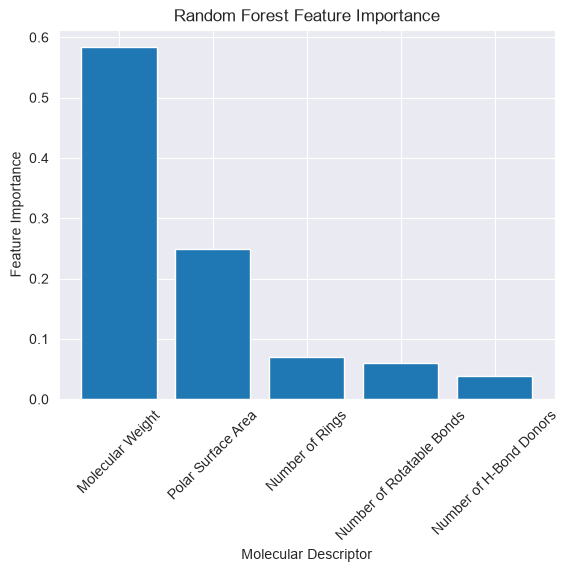

In [94]:
plt.bar(
    rf_importance["Feature"],
    rf_importance["Importance"]
)

plt.xlabel("Molecular Descriptor")
plt.ylabel("Feature Importance")
plt.title("Random Forest Feature Importance")
plt.xticks(rotation=45)
plt.show()

**Observation:** Molecular Weight has the highest feature importance in the Random Forest model, followed by Polar Surface Area. The Number of Rings, Number of Rotatable Bonds, and Number of H-Bond Donors contribute less to the model's predictions. These results suggest that Molecular Weight and Polar Surface Area are particularly useful descriptors for predicting solubility in this model. However, feature importance reflects how the Random Forest uses the variables for prediction and should not be interpreted as a direct measure of chemical causality.

### Cross-Validation

Five-fold cross-validation is used to evaluate the stability and generalization performance of the Random Forest model across different subsets of the dataset.

In [95]:
from sklearn.model_selection import cross_val_score

In [96]:
rf_cv_r2 = cross_val_score(
    rf_model,
    X,
    y,
    cv=5,
    scoring="r2"
)

rf_cv_r2

array([0.85912799, 0.81289181, 0.83366057, 0.82328006, 0.79363788])

In [97]:
rf_cv_r2_mean = round(rf_cv_r2.mean(), 2)
rf_cv_r2_std = round(rf_cv_r2.std(), 2)

print("Mean CV R²:", rf_cv_r2_mean)
print("Standard Deviation:", rf_cv_r2_std)

Mean CV R²: 0.82
Standard Deviation: 0.02


**Observation:** The Random Forest model achieved a mean 5-fold cross-validation R² of **0.82** with a standard deviation of **0.02**. The relatively small variation across folds suggests that the model's predictive performance is stable across different subsets of the dataset. The mean cross-validation R² is also close to the test-set R² of **0.83**, supporting the generalization performance observed in the original train-test split.

In [98]:
rf_tuned = RandomForestRegressor(
    n_estimators=100,
    max_depth=5,
    random_state=42
)

In [99]:
rf_tuned.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of t

In [100]:
rf_tuned_pred = rf_tuned.predict(X_test)

In [101]:
rf_tuned_mae = round(mean_absolute_error(y_test, rf_tuned_pred), 2)

rf_tuned_mae

0.72

In [102]:
rf_tuned_mse = mean_squared_error(y_test, rf_tuned_pred)
rf_tuned_rmse = round(np.sqrt(rf_tuned_mse), 2)

rf_tuned_rmse

np.float64(1.01)

In [103]:
rf_tuned_r2 = round(r2_score(y_test, rf_tuned_pred), 2)
rf_tuned_r2

0.79

In [104]:
print("Tuned RF MAE:", rf_tuned_mae)
print("Tuned RF RMSE:", rf_tuned_rmse)
print("Tuned RF R²:", rf_tuned_r2)

Tuned RF MAE: 0.72
Tuned RF RMSE: 1.01
Tuned RF R²: 0.79


In [105]:
rf_tuned_train_pred = rf_tuned.predict(X_train)

In [106]:
rf_tuned_pred = rf_tuned.predict(X_test)

In [107]:
rf_tuned_train_r2 = round(r2_score(y_train, rf_tuned_train_pred), 2)
rf_tuned_train_r2

0.84

### Hyperparameter Tuning with GridSearchCV

GridSearchCV is used to systematically evaluate different Random Forest hyperparameter combinations using cross-validation. The goal is to reduce overfitting while maintaining strong predictive performance.

In [108]:
from sklearn.model_selection import GridSearchCV

In [109]:
param_grid = {
    "max_depth": [5, 8, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

In [110]:
grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=5,
    scoring="r2"
)

In [111]:
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 8, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Con

In [112]:
grid_search.best_params_

{'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2}

In [113]:
best_rf_model = grid_search.best_estimator_

In [114]:
best_rf_pred = best_rf_model.predict(X_test)

In [115]:
best_rf_pred_mae = round(mean_absolute_error(y_test, best_rf_pred), 2)

best_rf_pred_mae

0.61

In [116]:
best_rf_pred_mse = mean_squared_error(y_test, best_rf_pred)
best_rf_pred_rmse = round(np.sqrt(best_rf_pred_mse), 2)

best_rf_pred_rmse

np.float64(0.9)

In [117]:
best_rf_pred_r2 = round(r2_score(y_test, best_rf_pred), 2)
best_rf_pred_r2

0.83

In [118]:
print("GridSearch RF MAE:", best_rf_pred_mae)
print("GridSearch RF RMSE:", best_rf_pred_rmse)
print("GridSearch RF R²:", best_rf_pred_r2)

GridSearch RF MAE: 0.61
GridSearch RF RMSE: 0.9
GridSearch RF R²: 0.83


**Observation:** GridSearchCV selected a Random Forest model with `max_depth=10`, `min_samples_leaf=1`, and `min_samples_split=2`. On the held-out test set, the tuned model achieved an **MAE of 0.61**, an **RMSE of 0.90**, and an **R² of 0.83**. Its test performance is very similar to the original Random Forest model, indicating that hyperparameter tuning maintained strong predictive performance while restricting the maximum tree depth.

In [119]:
best_rf_train_pred = best_rf_model.predict(X_train)

In [120]:
best_rf_train_r2 = round(r2_score(y_train, best_rf_train_pred), 2)
best_rf_train_r2

0.95

**Observation:** GridSearchCV selected a Random Forest model with `max_depth=10`, `min_samples_leaf=1`, and `min_samples_split=2`. The tuned model achieved an **MAE of 0.61**, an **RMSE of 0.90**, and an **R² of 0.83** on the held-out test set. Its training R² was **0.95**, compared with **0.97** for the original Random Forest. Therefore, limiting the tree depth slightly reduced the train-test performance gap while maintaining nearly identical test performance. However, some difference between training and test performance remains.

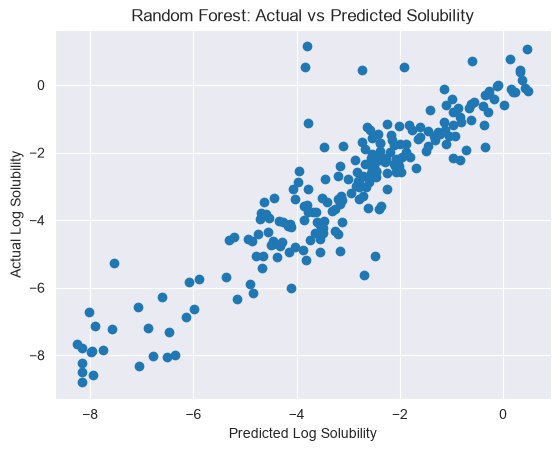

In [121]:
plt.scatter(best_rf_pred, y_test)

plt.xlabel("Predicted Log Solubility")
plt.ylabel("Actual Log Solubility")
plt.title("Random Forest: Actual vs Predicted Solubility")

plt.show()

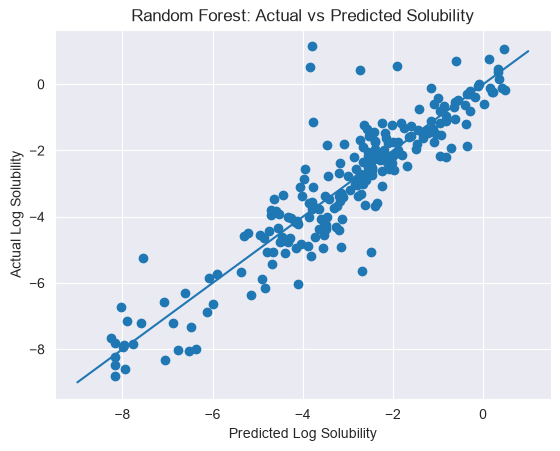

In [122]:
plt.scatter(best_rf_pred, y_test)
plt.plot([-9, 1], [-9, 1])

plt.xlabel("Predicted Log Solubility")
plt.ylabel("Actual Log Solubility")
plt.title("Random Forest: Actual vs Predicted Solubility")

plt.show()

**Observation:** Most predictions are distributed around the ideal prediction line (y = x), indicating that the tuned Random Forest model captures the overall relationship between predicted and measured solubility. However, several observations lie far from the ideal line, indicating relatively large prediction errors for some compounds.

In [123]:
best_rf_residuals = y_test - best_rf_pred

best_rf_residuals

1091   -0.070024
898     0.218099
739     0.065586
140    -0.070024
1019   -0.324560
          ...   
336    -0.863339
429     2.278899
12     -0.102431
1036   -0.040064
570    -0.235776
Name: measured log solubility in mols per litre, Length: 226, dtype: float64

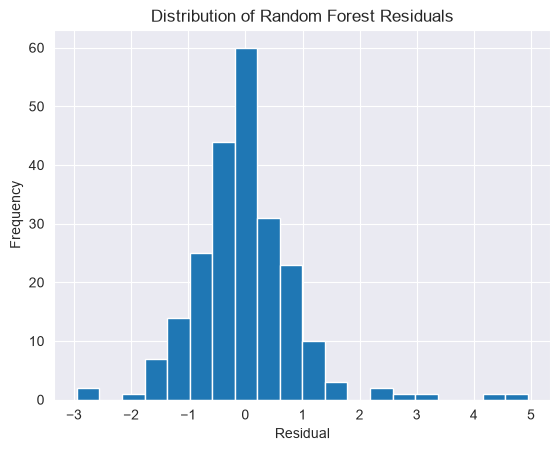

In [124]:
plt.hist(best_rf_residuals, bins=20)

plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Distribution of Random Forest Residuals")

plt.show()

In [125]:
best_rf_mean_residual = round(best_rf_residuals.mean(), 2)
best_rf_mean_residual

np.float64(-0.01)

### Random Forest Residual Analysis

The residual distribution was examined to evaluate the prediction errors of the tuned Random Forest model.

**Observation:** The residuals are concentrated around zero, with a mean residual of approximately **-0.01 logS units**. This indicates that the model does not show a strong systematic tendency to overpredict or underpredict solubility. However, several large residuals are present, particularly on the positive side of the distribution, indicating that the model substantially underpredicts solubility for a small number of compounds.

In [126]:
best_rf_absolute_errors = best_rf_residuals.abs()

In [127]:
top_10_errors = best_rf_absolute_errors.nlargest(10)
top_10_errors

1064    4.943930
292     4.368692
796     3.165256
96      2.948800
174     2.643844
56      2.568355
758     2.460246
429     2.278899
963     1.903027
548     1.757340
Name: measured log solubility in mols per litre, dtype: float64

In [128]:
df.loc[top_10_errors.index]

,Compound ID,ESOL predicted log solubility in mols per litre,Minimum Degree,Molecular Weight,Number of H-Bond Donors,Number of Rings,Number of Rotatable Bonds,Polar Surface Area,measured log solubility in mols per litre,smiles,Residual,Absolute Error,Squared Error
1064,vamidothion,-1.446,1,287.343,1,0,8,64.63,1.144,CNC(=O)C(C)SCCSP(=O)(OC)(OC),2.590,2.590,6.708100
292,Dimecron,-2.426,1,299.691,0,0,8,65.07,0.523,CCN(CC)C(=O)C(=CCOP(=O)(OC)OC)Cl,2.949,2.949,8.696601
796,Triethyl phosphate,-0.953,1,182.156,0,0,6,44.76,0.430,CCOP(=O)(OCC)OCC,1.383,1.383,1.912689
96,Chlorothalonil,-3.995,1,265.914,0,1,0,47.58,-5.640,c1(C#N)c(Cl)c(C#N)c(Cl)c(Cl)c(Cl)1,-1.645,1.645,2.706025
174,cycloheximide,-1.532,1,281.352,2,2,3,83.47,-1.130,CC1CC(C)C(=O)C(C1)C(O)CC2CC(=O)NC(=O)C2,0.402,0.402,0.161604
56,"2,2,5-Trimethylhexane",-3.631,1,128.259,0,0,2,0.00,-5.050,CC(C)CCC(C)(C)C,-1.419,1.419,2.013561
758,Acephate,-0.416,1,183.169,1,0,3,55.40,0.540,COP(=O)(NC(C)=O)SC,0.956,0.956,0.913936
429,Kepone,-5.112,1,490.639,0,6,0,17.07,-5.259,ClC1(C(=O)C2(Cl)C3(Cl)C14Cl)C5(Cl)C2(Cl)C3(Cl)...,-0.147,0.147,0.021609
963,difluron,-4.692,1,310.687,2,2,2,58.20,-6.020,Fc1cccc(F)c1C(=O)NC(=O)Nc2ccc(Cl)cc2,-1.328,1.328,1.763584
548,"Hexachloro-1,3-butadiene",-4.546,1,260.762,0,0,1,0.00,-4.920,ClC(=C(Cl)C(=C(Cl)Cl)Cl)Cl,-0.374,0.374,0.139876


In [129]:
df.loc[
    top_10_errors.index,
    ["Compound ID", "smiles"]
]

,Compound ID,smiles
1064,vamidothion,CNC(=O)C(C)SCCSP(=O)(OC)(OC)
292,Dimecron,CCN(CC)C(=O)C(=CCOP(=O)(OC)OC)Cl
796,Triethyl phosphate,CCOP(=O)(OCC)OCC
96,Chlorothalonil,c1(C#N)c(Cl)c(C#N)c(Cl)c(Cl)c(Cl)1
174,cycloheximide,CC1CC(C)C(=O)C(C1)C(O)CC2CC(=O)NC(=O)C2
56,"2,2,5-Trimethylhexane",CC(C)CCC(C)(C)C
758,Acephate,COP(=O)(NC(C)=O)SC
429,Kepone,ClC1(C(=O)C2(Cl)C3(Cl)C14Cl)C5(Cl)C2(Cl)C3(Cl)...
963,difluron,Fc1cccc(F)c1C(=O)NC(=O)Nc2ccc(Cl)cc2
548,"Hexachloro-1,3-butadiene",ClC(=C(Cl)C(=C(Cl)Cl)Cl)Cl


In [130]:
error_analysis = df.loc[
    top_10_errors.index,
    ["Compound ID", "smiles", "measured log solubility in mols per litre"]
].copy()
error_analysis

,Compound ID,smiles,measured log solubility in mols per litre
1064,vamidothion,CNC(=O)C(C)SCCSP(=O)(OC)(OC),1.144
292,Dimecron,CCN(CC)C(=O)C(=CCOP(=O)(OC)OC)Cl,0.523
796,Triethyl phosphate,CCOP(=O)(OCC)OCC,0.430
96,Chlorothalonil,c1(C#N)c(Cl)c(C#N)c(Cl)c(Cl)c(Cl)1,-5.640
174,cycloheximide,CC1CC(C)C(=O)C(C1)C(O)CC2CC(=O)NC(=O)C2,-1.130
56,"2,2,5-Trimethylhexane",CC(C)CCC(C)(C)C,-5.050
758,Acephate,COP(=O)(NC(C)=O)SC,0.540
429,Kepone,ClC1(C(=O)C2(Cl)C3(Cl)C14Cl)C5(Cl)C2(Cl)C3(Cl)...,-5.259
963,difluron,Fc1cccc(F)c1C(=O)NC(=O)Nc2ccc(Cl)cc2,-6.020
548,"Hexachloro-1,3-butadiene",ClC(=C(Cl)C(=C(Cl)Cl)Cl)Cl,-4.920


In [131]:
predictions_series = pd.Series(
    best_rf_pred,
    index=y_test.index
)

In [132]:
error_analysis["Predicted"] = predictions_series.loc[top_10_errors.index]
error_analysis

,Compound ID,smiles,measured log solubility in mols per litre,Predicted
1064,vamidothion,CNC(=O)C(C)SCCSP(=O)(OC)(OC),1.144,-3.799930
292,Dimecron,CCN(CC)C(=O)C(=CCOP(=O)(OC)OC)Cl,0.523,-3.845692
796,Triethyl phosphate,CCOP(=O)(OCC)OCC,0.430,-2.735256
96,Chlorothalonil,c1(C#N)c(Cl)c(C#N)c(Cl)c(Cl)c(Cl)1,-5.640,-2.691200
174,cycloheximide,CC1CC(C)C(=O)C(C1)C(O)CC2CC(=O)NC(=O)C2,-1.130,-3.773844
56,"2,2,5-Trimethylhexane",CC(C)CCC(C)(C)C,-5.050,-2.481645
758,Acephate,COP(=O)(NC(C)=O)SC,0.540,-1.920246
429,Kepone,ClC1(C(=O)C2(Cl)C3(Cl)C14Cl)C5(Cl)C2(Cl)C3(Cl)...,-5.259,-7.537899
963,difluron,Fc1cccc(F)c1C(=O)NC(=O)Nc2ccc(Cl)cc2,-6.020,-4.116973
548,"Hexachloro-1,3-butadiene",ClC(=C(Cl)C(=C(Cl)Cl)Cl)Cl,-4.920,-3.162660


In [133]:
error_analysis["Residual"] = (
    error_analysis["measured log solubility in mols per litre"]
    - error_analysis["Predicted"]
)

In [134]:
error_analysis["Absolute Error"] = error_analysis["Residual"].abs()
error_analysis

,Compound ID,smiles,measured log solubility in mols per litre,Predicted,Residual,Absolute Error
1064,vamidothion,CNC(=O)C(C)SCCSP(=O)(OC)(OC),1.144,-3.799930,4.943930,4.943930
292,Dimecron,CCN(CC)C(=O)C(=CCOP(=O)(OC)OC)Cl,0.523,-3.845692,4.368692,4.368692
796,Triethyl phosphate,CCOP(=O)(OCC)OCC,0.430,-2.735256,3.165256,3.165256
96,Chlorothalonil,c1(C#N)c(Cl)c(C#N)c(Cl)c(Cl)c(Cl)1,-5.640,-2.691200,-2.948800,2.948800
174,cycloheximide,CC1CC(C)C(=O)C(C1)C(O)CC2CC(=O)NC(=O)C2,-1.130,-3.773844,2.643844,2.643844
56,"2,2,5-Trimethylhexane",CC(C)CCC(C)(C)C,-5.050,-2.481645,-2.568355,2.568355
758,Acephate,COP(=O)(NC(C)=O)SC,0.540,-1.920246,2.460246,2.460246
429,Kepone,ClC1(C(=O)C2(Cl)C3(Cl)C14Cl)C5(Cl)C2(Cl)C3(Cl)...,-5.259,-7.537899,2.278899,2.278899
963,difluron,Fc1cccc(F)c1C(=O)NC(=O)Nc2ccc(Cl)cc2,-6.020,-4.116973,-1.903027,1.903027
548,"Hexachloro-1,3-butadiene",ClC(=C(Cl)C(=C(Cl)Cl)Cl)Cl,-4.920,-3.162660,-1.757340,1.757340


### Analysis of Largest Prediction Errors

**Observation:** The largest prediction errors occur for a small subset of compounds. Some compounds are substantially underpredicted, while others are overpredicted. This suggests that the five molecular descriptors used by the current model may not capture all structural factors affecting aqueous solubility. Examining molecular structures and incorporating additional cheminformatics descriptors may help explain these errors.

## 5. Cheminformatics with RDKit

In this section, molecular structures represented by SMILES strings are processed using RDKit. Molecular structures will be visualized and additional molecular descriptors will be calculated for further analysis and machine learning.

In [135]:
from rdkit import Chem

In [136]:
df["smiles"].iloc[0]

'OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)C(O)C3O '

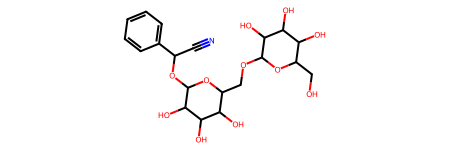

In [137]:
smiles = df["smiles"].iloc[0]

mol = Chem.MolFromSmiles(smiles)

mol

In [138]:
num_atoms = mol.GetNumAtoms()
num_atoms

32

In [139]:
atom_symbols = [atom.GetSymbol() for atom in mol.GetAtoms()]
atom_symbols


['O',
 'C',
 'C',
 'O',
 'C',
 'O',
 'C',
 'C',
 'O',
 'C',
 'O',
 'C',
 'C',
 'N',
 'C',
 'C',
 'C',
 'C',
 'C',
 'C',
 'C',
 'O',
 'C',
 'O',
 'C',
 'O',
 'C',
 'O',
 'C',
 'O',
 'C',
 'O']

In [140]:
carbon_count = atom_symbols.count("C")
oxygen_count = atom_symbols.count("O")
nitrogen_count = atom_symbols.count("N")

print("Carbon:", carbon_count)
print("Oxygen:", oxygen_count)
print("Nitrogen:", nitrogen_count)

Carbon: 20
Oxygen: 11
Nitrogen: 1


In [141]:
mol_with_h = Chem.AddHs(mol)

mol_with_h.GetNumAtoms()

59

In [142]:
atom_symbols_with_h = [
    atom.GetSymbol() for atom in mol_with_h.GetAtoms()
]

atom_symbols_with_h.count("H")

27

In [143]:
from rdkit.Chem import Descriptors

In [144]:
molecular_weight = Descriptors.MolWt(mol)
molecular_weight

457.4320000000001

In [145]:
print("Dataset MW:", df["Molecular Weight"].iloc[0])
print("RDKit MW:", round(molecular_weight, 2))

Dataset MW: 457.4320000000001
RDKit MW: 457.43


In [146]:
tpsa = Descriptors.TPSA(mol)
tpsa

202.31999999999996

In [147]:
tpsa = Descriptors.TPSA(mol)

print("Dataset PSA:", df["Polar Surface Area"].iloc[0])
print("RDKit TPSA:", tpsa)

Dataset PSA: 202.32
RDKit TPSA: 202.31999999999996


In [148]:
hbd = Descriptors.NumHDonors(mol)
hbd

7

In [149]:
df["Number of H-Bond Donors"].iloc[0]

np.int64(7)

In [150]:
hba = Descriptors.NumHAcceptors(mol)
hba

12

In [152]:
logp = Descriptors.MolLogP(mol)
logp

-3.1080199999999985

In [153]:
df["Mol"] = df["smiles"].apply(Chem.MolFromSmiles)

In [154]:
df["Mol"].isnull().sum()

np.int64(0)

In [155]:
df["LogP"] = df["Mol"].apply(Descriptors.MolLogP)

In [156]:
df[["Compound ID", "LogP"]].head()

,Compound ID,LogP
0,Amigdalin,-3.10802
1,Fenfuram,2.84032
2,citral,2.87800
3,Picene,6.29940
4,Thiophene,1.74810


In [157]:
df["HBA"] = df["Mol"].apply(Descriptors.NumHAcceptors)

In [158]:
df[["Compound ID", "LogP", "HBA"]].head()

,Compound ID,LogP,HBA
0,Amigdalin,-3.10802,12
1,Fenfuram,2.84032,2
2,citral,2.87800,1
3,Picene,6.29940,0
4,Thiophene,1.74810,1


In [159]:
Descriptors.FractionCSP3(mol)

0.65

In [161]:
df["FractionCSP3"] = df["Mol"].apply(Descriptors.FractionCSP3)

In [162]:
df[["Compound ID", "LogP", "HBA", "FractionCSP3"]].head()

,Compound ID,LogP,HBA,FractionCSP3
0,Amigdalin,-3.10802,0.650000,0.650000
1,Fenfuram,2.84032,0.083333,0.083333
2,citral,2.87800,0.500000,0.500000
3,Picene,6.29940,0.000000,0.000000
4,Thiophene,1.74810,0.000000,0.000000


In [163]:
df["LogP"].corr(
    df["measured log solubility in mols per litre"]
)

np.float64(-0.8279178849275888)

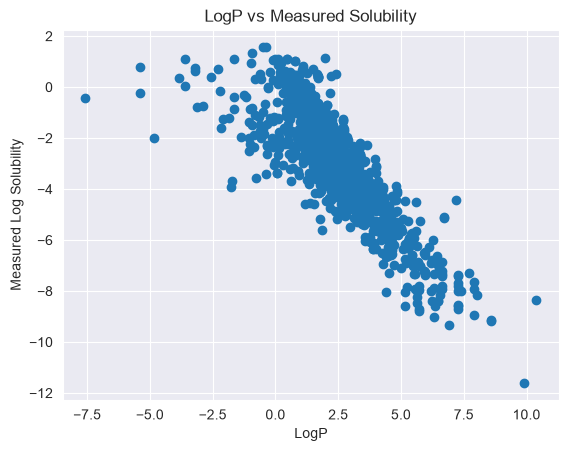

In [164]:
plt.scatter(
    df["LogP"],
    df["measured log solubility in mols per litre"]
)

plt.xlabel("LogP")
plt.ylabel("Measured Log Solubility")
plt.title("LogP vs Measured Solubility")

plt.show()

**Observation:** LogP shows a strong negative relationship with measured aqueous solubility, with a correlation coefficient of approximately **-0.82**. Compounds with higher LogP values tend to have lower measured log solubility. This suggests that lipophilicity is an important descriptor for predicting aqueous solubility in this dataset. However, the spread in the data indicates that LogP alone does not fully determine solubility.

In [165]:
df["HBA"].corr(
    df["measured log solubility in mols per litre"]
)

np.float64(0.22818287609906532)

In [166]:
df["FractionCSP3"].corr(
    df["measured log solubility in mols per litre"]
)

np.float64(0.22818287609906532)

### Random Forest with RDKit Descriptors

The newly calculated RDKit descriptors will be added to the original molecular features to investigate whether additional cheminformatics information improves solubility prediction.

In [167]:
X_rdkit = df[[
    "Molecular Weight",
    "Polar Surface Area",
    "Number of H-Bond Donors",
    "Number of Rings",
    "Number of Rotatable Bonds",
    "LogP",
    "HBA",
    "FractionCSP3"
]]

In [168]:
X_rdkit.shape

(1128, 8)

In [169]:
X_rdkit_train = X_rdkit.loc[y_train.index]
X_rdkit_test = X_rdkit.loc[y_test.index]

In [170]:
X_rdkit_train.shape
X_rdkit_test.shape

(226, 8)

In [171]:
X_rdkit_train.shape

(902, 8)

In [172]:
rf_rdkit_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [173]:
rf_rdkit_model.fit(X_rdkit_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [174]:
rf_rdkit_pred = rf_rdkit_model.predict(X_rdkit_test)

In [175]:
rf_rdkit_mae = round(mean_absolute_error(y_test, rf_rdkit_pred), 2)
rf_rdkit_mae

0.55

In [177]:
rf_rdkit_rmse = round(
    mean_squared_error(y_test, rf_rdkit_pred) ** 0.5,
    2
)

rf_rdkit_rmse

0.8

In [178]:
rf_rdkit_r2 = round(
    r2_score(y_test, rf_rdkit_pred),
    2
)
rf_rdkit_r2

0.86

**Observation:** Adding the RDKit-derived descriptors improved the Random Forest model's performance on the same held-out test set. The MAE decreased from **0.60 to 0.55**, the RMSE decreased from **0.91 to 0.80**, and the R² increased from **0.83 to 0.86**. This suggests that the additional cheminformatics descriptors provide useful information for predicting aqueous solubility beyond the original five molecular descriptors.

In [179]:
rf_rdkit_train_pred = rf_rdkit_model.predict(X_rdkit_train)

In [181]:
rf_rdkit_train_r2 = round(
    r2_score(y_train, rf_rdkit_train_pred),
    2
)
rf_rdkit_train_r2

0.98

**Observation:** The RDKit-enhanced Random Forest achieved a training R² of **0.98** and a test R² of **0.86**. The difference between training and test performance indicates that some overfitting remains. However, compared with the original Random Forest, the test R² improved from **0.83 to 0.86**, while the train-test R² gap decreased slightly from **0.14 to 0.12**. This suggests that the additional RDKit descriptors improved predictive performance without increasing the observed train-test gap.

In [182]:
rf_rdkit_model.feature_importances_

array([0.10011407, 0.04418589, 0.0065471 , 0.00984609, 0.00951424,
       0.81327086, 0.00825976, 0.008262  ])

In [183]:
rdkit_feature_importance = pd.Series(
    rf_rdkit_model.feature_importances_,
    index=X_rdkit.columns
)

In [184]:
rdkit_feature_importance = rdkit_feature_importance.sort_values(ascending=False)

rdkit_feature_importance

LogP                         0.813271
Molecular Weight             0.100114
Polar Surface Area           0.044186
Number of Rings              0.009846
Number of Rotatable Bonds    0.009514
FractionCSP3                 0.008262
HBA                          0.008260
Number of H-Bond Donors      0.006547
dtype: float64